In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.options.display.float_format = '{:.2f}'.format

HS_data = pd.read_csv('AICPA_regressionAnalysisData.csv')
HS_data['date'] = pd.to_datetime(HS_data['date'])

display(HS_data)

,type,date,revenue,production,coolDD,heatDD
0,dt4training,2011-01-31,23304096,659640,0,1021
1,dt4training,2011-02-28,24552000,686144,0,794
2,dt4training,2011-03-31,14804728,416464,0,714
3,dt4training,2011-04-30,11265320,324456,1,354
4,dt4training,2011-05-31,5945904,151104,72,114
5,dt4training,2011-06-30,10379712,479264,239,4
6,dt4training,2011-07-31,13617528,708472,486,0
7,dt4training,2011-08-31,14092512,687728,346,0
8,dt4training,2011-09-30,12085472,567424,195,19
9,dt4training,2011-10-31,11957032,392328,24,223


In [ ]:
#Creating dummy variables, winter is December, January and February and defining them as winter or non-winter months
HS_data['winter_DV'] = np.where(HS_data['date'].dt.month.isin([12,1,2]),1,0)
HS_data['winter_interaction'] = HS_data['production'] * HS_data['winter_DV']

display(HS_data)

,type,date,revenue,production,coolDD,heatDD,winter_DV,winter_interaction
0,dt4training,2011-01-31,23304096,659640,0,1021,1,659640
1,dt4training,2011-02-28,24552000,686144,0,794,1,686144
2,dt4training,2011-03-31,14804728,416464,0,714,0,0
3,dt4training,2011-04-30,11265320,324456,1,354,0,0
4,dt4training,2011-05-31,5945904,151104,72,114,0,0
5,dt4training,2011-06-30,10379712,479264,239,4,0,0
6,dt4training,2011-07-31,13617528,708472,486,0,0,0
7,dt4training,2011-08-31,14092512,687728,346,0,0,0
8,dt4training,2011-09-30,12085472,567424,195,19,0,0
9,dt4training,2011-10-31,11957032,392328,24,223,0,0


In [ ]:
#Classifying the data into training or testing

dt4training = HS_data.loc[HS_data['type'] == 'dt4training']
dt4testing = HS_data.loc[HS_data['type'] == 'dt4testing']

display(dt4training)
display(dt4testing)

,type,date,revenue,production,coolDD,heatDD,winter_DV,winter_interaction
0,dt4training,2011-01-31,23304096,659640,0,1021,1,659640
1,dt4training,2011-02-28,24552000,686144,0,794,1,686144
2,dt4training,2011-03-31,14804728,416464,0,714,0,0
3,dt4training,2011-04-30,11265320,324456,1,354,0,0
4,dt4training,2011-05-31,5945904,151104,72,114,0,0
5,dt4training,2011-06-30,10379712,479264,239,4,0,0
6,dt4training,2011-07-31,13617528,708472,486,0,0,0
7,dt4training,2011-08-31,14092512,687728,346,0,0,0
8,dt4training,2011-09-30,12085472,567424,195,19,0,0
9,dt4training,2011-10-31,11957032,392328,24,223,0,0


,type,date,revenue,production,coolDD,heatDD,winter_DV,winter_interaction
36,dt4testing,2014-01-31,19228840,606400,0,1123,1,606400
37,dt4testing,2014-02-28,26792280,714128,0,938,1,714128
38,dt4testing,2014-03-31,19935840,805600,0,866,0,0
39,dt4testing,2014-04-30,13468000,375856,0,412,0,0
40,dt4testing,2014-05-31,7344128,279296,49,88,0,0
41,dt4testing,2014-06-30,11196216,517600,230,0,0,0
42,dt4testing,2014-07-31,13929472,749472,380,0,0,0
43,dt4testing,2014-08-31,12352176,663432,322,0,0,0
44,dt4testing,2014-09-30,12628944,701656,178,14,0,0
45,dt4testing,2014-10-31,9361000,411728,24,166,0,0


In [ ]:
#Training the model
y = dt4training.loc[:,'revenue']
x = dt4training.loc[:,['production','winter_DV','winter_interaction']]
x = sm.add_constant(x)

model1 = sm.OLS(y,x).fit()
model1.params

,0
const,5629257.08
production,13.51
winter_DV,-201742.73
winter_interaction,14.16


In [ ]:
# Testing the model and calculating the MAPE
x_test = dt4testing.loc[:,['production','winter_DV','winter_interaction']]
x_test = sm.add_constant(x_test)

model1_assessment = dt4testing.copy()
model1_assessment['model1_predicted_revenue'] = model1.predict(x_test)
model1_assessment['model1_abs_pct_error'] = abs((model1_assessment['revenue'] - model1_assessment['model1_predicted_revenue'])/model1_assessment['revenue'])

display(model1_assessment)

,type,date,revenue,production,coolDD,heatDD,winter_DV,winter_interaction,model1_predicted_revenue,model1_abs_pct_error
36,dt4testing,2014-01-31,19228840,606400,0,1123,1,606400,22205317.42,0.15
37,dt4testing,2014-02-28,26792280,714128,0,938,1,714128,25185922.91,0.06
38,dt4testing,2014-03-31,19935840,805600,0,866,0,0,16509348.78,0.17
39,dt4testing,2014-04-30,13468000,375856,0,412,0,0,10705408.70,0.21
40,dt4testing,2014-05-31,7344128,279296,49,88,0,0,9401310.32,0.28
41,dt4testing,2014-06-30,11196216,517600,230,0,0,0,12619743.01,0.13
42,dt4testing,2014-07-31,13929472,749472,380,0,0,0,15751307.84,0.13
43,dt4testing,2014-08-31,12352176,663432,322,0,0,0,14589288.11,0.18
44,dt4testing,2014-09-30,12628944,701656,178,14,0,0,15105525.23,0.20
45,dt4testing,2014-10-31,9361000,411728,24,166,0,0,11189880.71,0.20


np.float64(0.15896219012848184)

In [ ]:
model1_assessment['model1_abs_pct_error'].mean()

np.float64(0.15896219012848184)

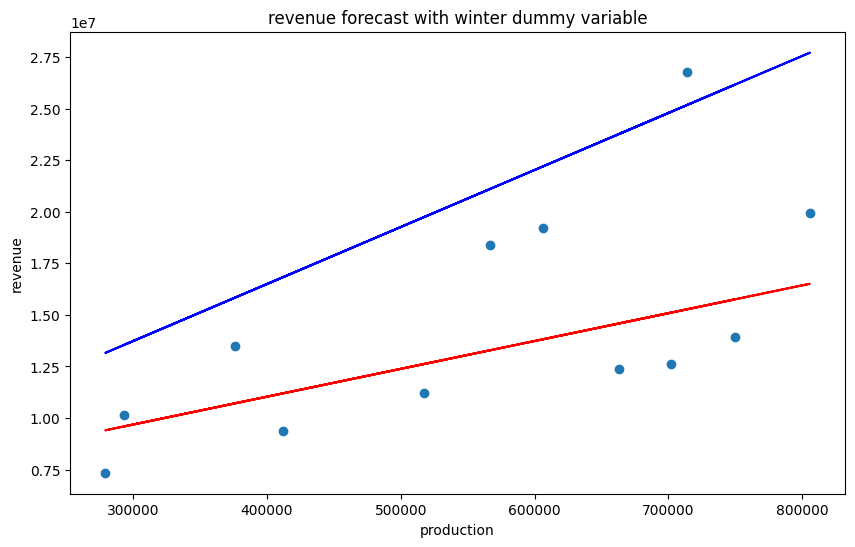

In [ ]:
#Visualize the model
plt.figure(figsize=(10,6))

plt.title('revenue forecast with winter dummy variable')
plt.xlabel('production')
plt.ylabel('revenue')

plt.scatter(dt4testing['production'], dt4testing['revenue'])

intercept, production_coefficient, winter_DV_intercept, winter_coefficient = model1.params

non_winter_line = intercept + production_coefficient * dt4testing['production']

winter_line = (intercept + winter_DV_intercept) + (production_coefficient + winter_coefficient) * dt4testing['production']

plt.plot(dt4testing['production'], non_winter_line, color='red')
plt.plot(dt4testing['production'], winter_line, color='blue')